In [1]:
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import friedmanchisquare
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
uy_metrics = Path("./peak_metrics/uruguay")
us_results = Path("./peak_metrics/united_states")

# US

In [5]:
df_results_us = pd.read_csv(us_results / "peak_metrics.csv")
df_results_us

,basin,product,peak_timing,missed_peaks,mape_peak
0,1411300,CARAVAN,0.285714,0.652778,46.350719
1,1411300,CHIRPS,0.257143,0.416667,38.703938
2,1411300,MSWEP,0.228571,0.319444,27.217615
3,1466500,CARAVAN,0.579710,0.785714,52.975071
4,1466500,CHIRPS,0.521739,0.600000,43.559859
...,...,...,...,...,...
376,12073500,CHIRPS,0.200000,0.507692,32.668108
377,12073500,MSWEP,0.076923,0.369231,18.396750
378,14362250,CARAVAN,0.723077,0.476923,44.130249
379,14362250,CHIRPS,0.338462,0.400000,37.595931


In [6]:
# ── Friedman test ─────────────────────────────────────────────────────────────
def friedman_test(df, metric_name):
    data = [df[col].dropna().values for col in df.columns]
    stat, p = friedmanchisquare(*data)

    k = len(df.columns)
    n = len(df)
    W = stat / (n * (k - 1))

    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"

    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²           = {stat:.4f}")
    print(f"  p-value      = {p:.4f}")
    print(f"  Kendall W    = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'Significant difference between models (p < 0.05)' if p < 0.05 else 'No significant difference between models (p >= 0.05)'}")

    return stat, p, W

In [7]:
metric_names = ['Peak-MAPE', 'Missed-Peaks', 'Peak-Timing']

# Column mapping from df_results_us to your metric names
col_map = {
    'Peak-MAPE':    'mape_peak',
    'Missed-Peaks': 'missed_peaks',
    'Peak-Timing':  'peak_timing',
}

# ── Build per-metric DataFrames by pivoting df_results_us ────────────────────
# Each df: index = basin, columns = product (CARAVAN, CHIRPS, MSWEP)
metric_dfs = {
    metric: df_results_us.pivot(index='basin', columns='product', values=col_map[metric])
    for metric in metric_names
}

# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 210.3465
  p-value      = 0.0000
  Kendall W    = 0.8281 (large effect)
  n catchments = 127, k models = 3

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 177.5230
  p-value      = 0.0000
  Kendall W    = 0.6989 (large effect)
  n catchments = 127, k models = 3

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 193.3241
  p-value      = 0.0000
  Kendall W    = 0.7611 (large effect)
  n catchments = 127, k models = 3

  Significant difference between models (p < 0.05)


In [8]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(2.1078868046837216e-46),
 'Missed-Peaks': np.float64(2.8272247609871335e-39),
 'Peak-Timing': np.float64(1.0476463459026347e-42)}

In [9]:
metric_targets = {
    'Peak-MAPE': 0,
    'Missed-Peaks': 0,
    'Peak-Timing': 0,
}

In [10]:
def posthoc_wilcoxon(df, metric_name, friedman_p, metric_targets):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs  = list(itertools.combinations(models, 2))
    target = metric_targets[metric_name]
    
    rows = []
    for m1, m2 in pairs:
        diff      = df[m1].values - df[m2].values
        n_zeros   = (diff == 0).sum()
        n_effective = len(diff) - n_zeros

        if n_zeros > 0:
            print(f"  ⚠️  {metric_name} | {m1} vs {m2}: "
                  f"{n_zeros} tied pairs dropped (n_effective={n_effective})")

        stat, p_raw    = wilcoxon(df[m1].values, df[m2].values)
        median_diff    = np.median(diff)          # >0 → m1 tends higher, <0 → m2 tends higher
        median_m1      = df[m1].median()
        median_m2      = df[m2].median()

        # Direction: which model is closer to the target?
        # if abs(median_m1 - target) < abs(median_m2 - target):
        #     better = m1
        # elif abs(median_m2 - target) < abs(median_m1 - target):
        #     better = m2
        # else:
        #     better = 'tie'

        # Direction:
        dist_m1 = abs(median_m1 - target)
        dist_m2 = abs(median_m2 - target)

        if dist_m1 < dist_m2:
            better = m1
        elif dist_m2 < dist_m1:
            better = m2
        else:
            better = 'tie'

        rows.append({
            'model_1':      m1,
            'model_2':      m2,
            'median_m1':    median_m1,
            'median_m2':    median_m2,
            'median_diff':  median_diff,
            'better':       better,
            'p_raw':        p_raw,
            'n_zeros':      n_zeros,
            'n_effective':  n_effective,
        })
    
    results_df = pd.DataFrame(rows)
    
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05

    print(f"\n{'='*80}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}  (target = {target})")
    print(f"{'='*80}")
    for _, row in results_df.iterrows():
        if row['significant']:
            sig = f"* {row['better']} better"
        else:
            sig = "  similar"
        zeros = f"  [⚠️  {int(row['n_zeros'])} ties]" if row['n_zeros'] > 0 else ""
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"med=({row['median_m1']:.3f} | {row['median_m2']:.3f})  "
              f"p_adj={row['p_corrected']:.4f}  {sig}{zeros}")
    
    return results_df


# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  CARAVAN              vs CHIRPS                med=(63.168 | 42.812)  p_adj=0.0000  * CHIRPS better
  CARAVAN              vs MSWEP                 med=(63.168 | 38.536)  p_adj=0.0000  * MSWEP better
  CHIRPS               vs MSWEP                 med=(42.812 | 38.536)  p_adj=0.0000  * MSWEP better
  ⚠️  Missed-Peaks | CARAVAN vs CHIRPS: 1 tied pairs dropped (n_effective=126)
  ⚠️  Missed-Peaks | CARAVAN vs MSWEP: 1 tied pairs dropped (n_effective=126)
  ⚠️  Missed-Peaks | CHIRPS vs MSWEP: 7 tied pairs dropped (n_effective=120)

  Wilcoxon signed-rank + Bonferroni — Missed-Peaks  (target = 0)
  CARAVAN              vs CHIRPS                med=(0.632 | 0.479)  p_adj=0.0000  * CHIRPS better  [⚠️  1 ties]
  CARAVAN              vs MSWEP                 med=(0.632 | 0.403)  p_adj=0.0000  * MSWEP better  [⚠️  1 ties]
  CHIRPS               vs MSWEP                 med=(0.479 | 0.403)  p_adj=0.0000  * MSWEP better  [⚠️  7 ties]

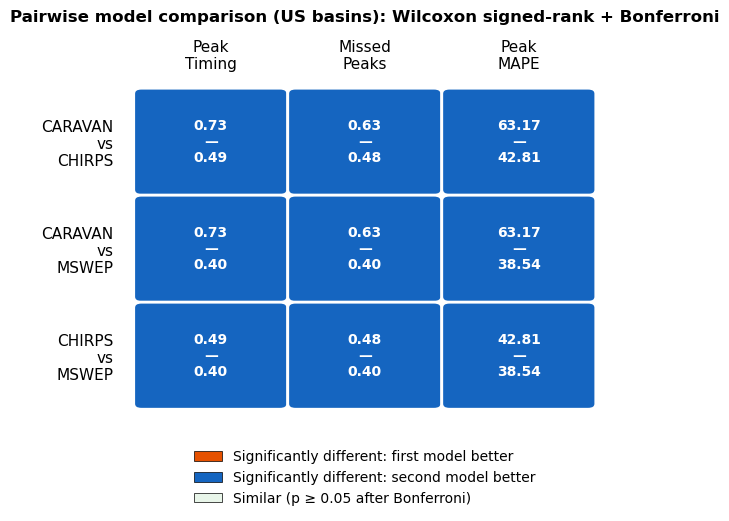

In [11]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['CARAVAN', 'CHIRPS', 'MSWEP']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first' if better == m1 else 'second'
    else:
        return 'first' if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────
metrics_list = ['Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs       = list(itertools.combinations(range(len(models)), 2))
pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))   # smaller — only 3x3 grid
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')

ax.set_xlim(-0.6, len(metrics_list) - 0.4)
ax.set_ylim(len(pairs) - 0.4, -0.6)
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11)
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(pair_labels, fontsize=11)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better',  edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)',          edgecolor='black', linewidth=0.5),
]

ax.set_title(
    'Pairwise model comparison (US basins): Wilcoxon signed-rank + Bonferroni',
    fontsize=12, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.05), ncol=1,
          frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# UY

In [12]:
df_results_uy = pd.read_csv(uy_metrics / "peak_metrics.csv")

In [13]:
metric_dfs = {
    metric: df_results_us.pivot(index='basin', columns='product', values=col_map[metric])
    for metric in metric_names
}

# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 210.3465
  p-value      = 0.0000
  Kendall W    = 0.8281 (large effect)
  n catchments = 127, k models = 3

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 177.5230
  p-value      = 0.0000
  Kendall W    = 0.6989 (large effect)
  n catchments = 127, k models = 3

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 193.3241
  p-value      = 0.0000
  Kendall W    = 0.7611 (large effect)
  n catchments = 127, k models = 3

  Significant difference between models (p < 0.05)


In [14]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  CARAVAN              vs CHIRPS                med=(63.168 | 42.812)  p_adj=0.0000  * CHIRPS better
  CARAVAN              vs MSWEP                 med=(63.168 | 38.536)  p_adj=0.0000  * MSWEP better
  CHIRPS               vs MSWEP                 med=(42.812 | 38.536)  p_adj=0.0000  * MSWEP better
  ⚠️  Missed-Peaks | CARAVAN vs CHIRPS: 1 tied pairs dropped (n_effective=126)
  ⚠️  Missed-Peaks | CARAVAN vs MSWEP: 1 tied pairs dropped (n_effective=126)
  ⚠️  Missed-Peaks | CHIRPS vs MSWEP: 7 tied pairs dropped (n_effective=120)

  Wilcoxon signed-rank + Bonferroni — Missed-Peaks  (target = 0)
  CARAVAN              vs CHIRPS                med=(0.632 | 0.479)  p_adj=0.0000  * CHIRPS better  [⚠️  1 ties]
  CARAVAN              vs MSWEP                 med=(0.632 | 0.403)  p_adj=0.0000  * MSWEP better  [⚠️  1 ties]
  CHIRPS               vs MSWEP                 med=(0.479 | 0.403)  p_adj=0.0000  * MSWEP better  [⚠️  7 ties]

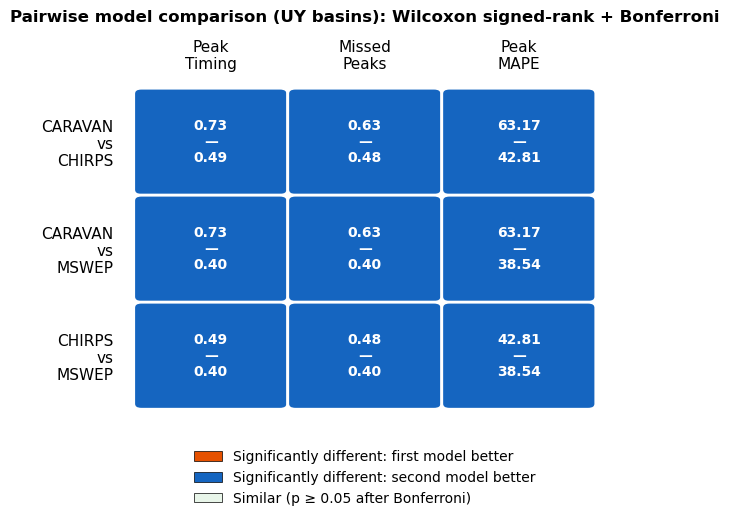

In [15]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['CARAVAN', 'CHIRPS', 'MSWEP']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first' if better == m1 else 'second'
    else:
        return 'first' if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────
metrics_list = ['Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs       = list(itertools.combinations(range(len(models)), 2))
pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))   # smaller — only 3x3 grid
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')

ax.set_xlim(-0.6, len(metrics_list) - 0.4)
ax.set_ylim(len(pairs) - 0.4, -0.6)
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11)
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(pair_labels, fontsize=11)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better',  edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)',          edgecolor='black', linewidth=0.5),
]

ax.set_title(
    'Pairwise model comparison (UY basins): Wilcoxon signed-rank + Bonferroni',
    fontsize=12, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.05), ncol=1,
          frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()